In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from IPython.display import display
import warnings
warnings.simplefilter('ignore')


df = pd.read_excel('AmesHousing.xlsx')


df = df.drop('ID', axis=1)

print(" Data  loaded Total houses:", len(df))

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [ ]:
# Import the safe type-checker from Pandas
from pandas.api.types import is_numeric_dtype

# --- TASK 2: HANDLE MISSING VALUES ---
# We loop through every single column in the dataset
for col in df.columns:
    
    # Safely check if the column contains numbers (int/float)
    if is_numeric_dtype(df[col]):
        # Fill any empty cells with the middle value (the median)
        df[col] = df[col].fillna(df[col].median())
        
    # If it is NOT a number (meaning it is text, strings, or categories)
    else:
        # Fill any empty cells with the most frequent text (the mode)
        df[col] = df[col].fillna(df[col].mode()[0])

# --- TASK 3: ONE-HOT ENCODING ---
# get_dummies converts every text category into its own column with 1s and 0s.
df_encoded = pd.get_dummies(df, drop_first=True)

# --- TASK 1: SPLIT X AND Y ---
# X contains all the features (everything EXCEPT SalePrice)
X = df_encoded.drop('SalePrice', axis=1)
# y is our target: the exact dollar amount we want to predict
y = df_encoded['SalePrice']

# SCALING: House prices and square footage are massive numbers. We must scale X down!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

print(f"The data now has {X.shape[1]} encoded columns.")

The data now has 42 encoded columns.


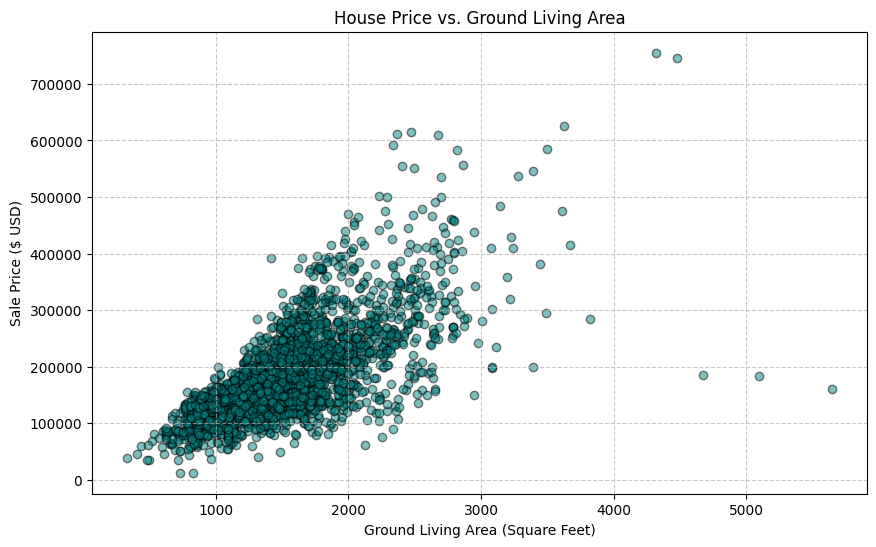

In [ ]:
# Create a blank drawing canvas
plt.figure(figsize=(10, 6))

# Draw a scatter plot comparing Living Area (X) to House Price (Y)
plt.scatter(df['Gr Liv Area'], df['SalePrice'], color='teal', alpha=0.5, edgecolor='black')

# Add titles and labels
plt.title('House Price vs. Ground Living Area')
plt.xlabel('Ground Living Area (Square Feet)')
plt.ylabel('Sale Price ($ USD)')

# Format the Y-axis to show regular numbers instead of scientific notation (e.g., 200000 instead of 2e5)
plt.ticklabel_format(style='plain', axis='y')

# Add a grid to make it easier to read
plt.grid(True, linestyle='--', alpha=0.7)
# Render the plot
plt.show()

In [ ]:
print("--- RUNNING WARM-UP TEST ---")

test_model = Sequential()

test_model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
# --- TASK 4: LINEAR OUTPUT ---

test_model.add(Dense(1, activation='linear'))

# --- TASK 5: MAE & MSE ---
# Loss = mean_squared_error (penalizes huge mistakes heavily)
# Metrics = mean_absolute_error (tells us exactly how many dollars we are off by on average)
test_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

# Train the test model for 10 epochs
test_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

print("\n--- TEST PREDICTIONS ---")
# Predict the price of the first 5 test houses
y_pred_prices = test_model.predict(X_test[:5]) 

# Loop through the predictions and compare them to the actual prices
for i, prediction in enumerate(y_pred_prices):
    actual_price = y_test.iloc[i]
    predicted_price = prediction[0]
    error = abs(actual_price - predicted_price)
    print(f"House {i+1}: Guessed ${predicted_price:,.0f} | Actual ${actual_price:,.0f} | Off by: ${error:,.0f}")

--- RUNNING WARM-UP TEST ---
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 37836574720.0000 - mae: 178580.2344  
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - loss: 37834866688.0000 - mae: 178576.1562
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37832073216.0000 - mae: 178569.8125  
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37827686400.0000 - mae: 178560.3281  
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37821239296.0000 - mae: 178546.5312  
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 37812510720.0000 - mae: 178528.1875  
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - loss: 37801160704.0000 - mae: 178504.4688
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - loss: 37787029504.0000 - mae: 178475.1250
Epoch 9/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 37769883648.0000 - mae: 178440.3594
Epoch 10/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - loss: 37749940224.0000 - mae: 178399.4062

--- TEST 

In [ ]:
# Our blueprint of 10 different network architectures
experiments = [
    {'id': 1, 'layers': 1, 'nodes': [32], 'epochs': 50, 'batch': 32, 'lr': 0.01, 'note': 'Baseline'},
    {'id': 2, 'layers': 1, 'nodes': [64], 'epochs': 50, 'batch': 32, 'lr': 0.01, 'note': 'Wider'},
    {'id': 3, 'layers': 2, 'nodes': [64, 32], 'epochs': 50, 'batch': 32, 'lr': 0.01, 'note': 'Deeper'},
    {'id': 4, 'layers': 2, 'nodes': [128, 64], 'epochs': 50, 'batch': 32, 'lr': 0.01, 'note': 'Very Wide'},
    {'id': 5, 'layers': 3, 'nodes': [128, 64, 32], 'epochs': 50, 'batch': 32, 'lr': 0.01, 'note': '3 Layers'},
    {'id': 6, 'layers': 2, 'nodes': [64, 32], 'epochs': 100, 'batch': 32, 'lr': 0.01, 'note': 'More Epochs'},
    {'id': 7, 'layers': 2, 'nodes': [64, 32], 'epochs': 50, 'batch': 32, 'lr': 0.1, 'note': 'High LR'},
    {'id': 8, 'layers': 2, 'nodes': [64, 32], 'epochs': 50, 'batch': 32, 'lr': 0.001, 'note': 'Low LR'},
    {'id': 9, 'layers': 2, 'nodes': [64, 32], 'epochs': 50, 'batch': 128, 'lr': 0.01, 'note': 'Big Batch'},
    {'id': 10, 'layers': 3, 'nodes': [256, 128, 64], 'epochs': 100, 'batch': 32, 'lr': 0.001, 'note': 'Max Power'}
]

results = []
print("Starting 10 Regression Experiments...\n")

# Loop through all 10 blueprints
for exp in experiments:
    model = Sequential()
    
    # Build hidden layers dynamically
    for i in range(exp['layers']):
        if i == 0:
            model.add(Dense(exp['nodes'][i], activation='relu', input_dim=X_train.shape[1]))
        else:
            model.add(Dense(exp['nodes'][i], activation='relu'))
            
    # Final layer: 1 node, linear activation for price prediction
    model.add(Dense(1, activation='linear')) 
    
    # Compile using MSE for loss and MAE for our human-readable metric
    model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=exp['lr']), metrics=['mae'])
    # Train the model silently (verbose=0)
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    
    # Evaluate the model. Returns MSE (loss) and MAE (Mean Absolute Error)
    mse, mae = model.evaluate(X_test, y_test, verbose=0)
    
    # Save the results. Remember: We want the LOWEST MAE!
    results.append({
        'Experiment ID': exp['id'],
        'Description': exp['note'],
        'Epochs': exp['epochs'],
        'MAE (Error in $)': round(mae, 2)
    })
    print(f" Exp {exp['id']} done! -> Average Error: ${mae:,.0f}")

# Convert to a DataFrame and sort by the LOWEST error at the top!
df_results = pd.DataFrame(results).sort_values(by='MAE (Error in $)')
display(df_results)

Starting 10 Regression Experiments...



 Exp 1 done! -> Average Error: $38,879
 Exp 2 done! -> Average Error: $28,977
 Exp 3 done! -> Average Error: $20,028
 Exp 4 done! -> Average Error: $19,346
 Exp 5 done! -> Average Error: $19,020
 Exp 6 done! -> Average Error: $18,498
 Exp 7 done! -> Average Error: $21,541
 Exp 8 done! -> Average Error: $33,577
 Exp 9 done! -> Average Error: $23,039
 Exp 10 done! -> Average Error: $18,814


,Experiment ID,Description,Epochs,MAE (Error in $)
5,6,More Epochs,100,18497.87
9,10,Max Power,100,18814.50
4,5,3 Layers,50,19019.74
3,4,Very Wide,50,19346.37
2,3,Deeper,50,20028.13
6,7,High LR,50,21541.42
8,9,Big Batch,50,23039.34
1,2,Wider,50,28976.69
7,8,Low LR,50,33576.85
0,1,Baseline,50,38878.89


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- FINAL MODEL PERFORMANCE ---
Mean Absolute Error (MAE): $22,336
R-Squared (R2) Score: 0.8593


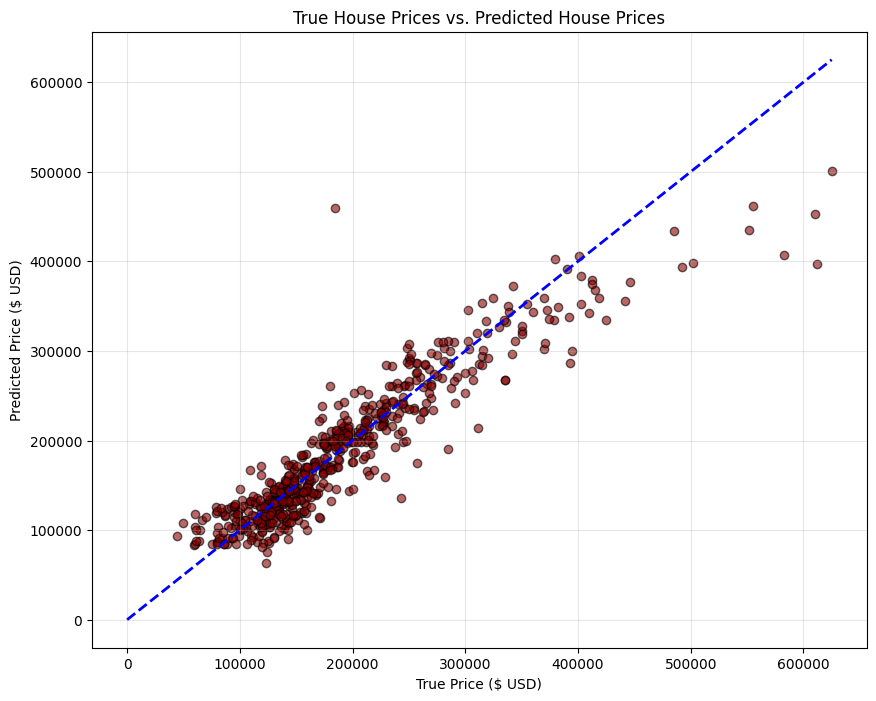

In [ ]:
final_model = Sequential()
final_model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
final_model.add(Dense(32, activation='relu'))
final_model.add(Dense(1, activation='linear'))

# Train the champion model
final_model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001), metrics=['mae'])
# We use 150 epochs to give it maximum time to adjust its weights for precise dollars
final_model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)

# Make predictions on the hidden test set
y_pred = final_model.predict(X_test)

# Calculate final grading metrics
final_mae = mean_absolute_error(y_test, y_pred)
# R2 Score measures how well our predictions match reality. 1.0 is perfect, 0 is terrible.
final_r2 = r2_score(y_test, y_pred)

print("\n--- FINAL MODEL PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): ${final_mae:,.0f}")
print(f"R-Squared (R2) Score: {final_r2:.4f}")

# --- REGRESSION VISUALIZATION: TRUE VS PREDICTED ---
# we plot the Actual Prices against the Predicted Prices.
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, color='darkred', alpha=0.6, edgecolor='black')

# Draw a perfect 45-degree diagonal line. 
# If our model was 100% perfect, every dot would sit exactly on this line.
max_price = max(y_test.max(), y_pred.max())
plt.plot([0, max_price], [0, max_price], color='blue', linewidth=2, linestyle='--')

plt.title('True House Prices vs. Predicted House Prices')
plt.xlabel('True Price ($ USD)')
plt.ylabel('Predicted Price ($ USD)')
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, alpha=0.3)
plt.show()